## GINN `best.pt` 推理与剖面对比

这个 notebook 会完成三件事：

1. 从 `experiments/ginn/checkpoints/best.pt` 加载训练好的模型。
2. 使用 `Trainer.predict_volume()` 对整个体做预测，得到阻抗体。
3. 在同一位置切出预测阻抗剖面和低频模型剖面，并排对比，同时给出差值剖面。


In [1]:
import sys
from pathlib import Path

import cigsegy
import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from ginn.config import GINNConfig
from ginn.trainer import Trainer

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False


In [2]:
checkpoint_path = repo_root / "experiments" / "ginn" / "checkpoints" / "best.pt"
output_dir = repo_root / "data" / "output_ginn_prediction"
output_dir.mkdir(parents=True, exist_ok=True)

slice_mode = "inline"  # 可选: "inline" 或 "xline"
slice_index = None  # None 表示默认取中间剖面
clip_percentiles = (1.0, 99.0)
ai_display_min = 0.0
ai_display_max = 20000.0

if not checkpoint_path.exists():
    raise FileNotFoundError(checkpoint_path)

checkpoint_path

WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/experiments/ginn/checkpoints/best.pt')

In [3]:
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
cfg_payload = checkpoint["config"]
cfg = GINNConfig.from_dict(cfg_payload) if isinstance(cfg_payload, dict) else cfg_payload
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

trainer = Trainer(cfg)
trainer.model.load_state_dict(checkpoint["model_state_dict"])
trainer.model.eval()

print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Epoch: {checkpoint['epoch']}")
print(f"Best loss: {checkpoint['best_loss']:.6f}")
print(f"Device: {trainer.device}")
print(f"Geometry: {trainer.geometry}")


100%|██████████| 361201/361201 [00:00<00:00, 1488300.09it/s]


Loaded checkpoint: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\ginn\checkpoints\best.pt
Epoch: 11
Best loss: 0.031748
Device: cuda
Geometry: {'n_il': 601, 'inline_min': 1501.0, 'inline_max': 2101.0, 'inline_step': 1.0, 'n_xl': 601, 'xline_min': 4199.0, 'xline_max': 6599.0, 'xline_step': 4.0, 'n_sample': 1201, 'sample_min': 4.8, 'sample_max': 6.0, 'sample_step': 0.001000000000000334, 'sample_domain': 'time', 'sample_unit': 's'}


In [4]:
pred_volume = trainer.predict_volume()

n_il = int(trainer.geometry["n_il"])
n_xl = int(trainer.geometry["n_xl"])
n_sample = int(trainer.geometry["n_sample"])

lfm_volume = trainer.dataset._lfm_flat.reshape(n_il, n_xl, n_sample)
mask_volume = trainer.dataset._mask_flat.reshape(n_il, n_xl, n_sample)

prediction_path = output_dir / "pred_volume_best.npy"
np.save(prediction_path, pred_volume.astype(np.float32))

print("Prediction volume shape:", pred_volume.shape)
print("LFM volume shape:", lfm_volume.shape)
print("Mask volume shape:", mask_volume.shape)
print("Saved prediction to:", prediction_path)


Prediction volume shape: (601, 601, 1201)
LFM volume shape: (601, 601, 1201)
Mask volume shape: (601, 601, 1201)
Saved prediction to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_prediction\pred_volume_best.npy


In [5]:
def resolve_slice_index(mode: str, index: int | None, geometry: dict) -> int:
    if mode not in {"inline", "xline"}:
        raise ValueError(f"slice_mode must be 'inline' or 'xline', got {mode!r}")
    size = int(geometry["n_il"] if mode == "inline" else geometry["n_xl"])
    if index is None:
        return size // 2
    if not (0 <= index < size):
        raise IndexError(f"slice_index={index} out of range for {mode} size={size}")
    return index


def extract_section(volume: np.ndarray, mode: str, index: int) -> np.ndarray:
    if mode == "inline":
        return volume[index, :, :].T
    if mode == "xline":
        return volume[:, index, :].T
    raise ValueError(mode)


def extract_mask_section(mask: np.ndarray, mode: str, index: int) -> np.ndarray:
    if mode == "inline":
        return mask[index, :, :].T
    if mode == "xline":
        return mask[:, index, :].T
    raise ValueError(mode)


def robust_limits(*arrays: np.ndarray, percentiles=(1.0, 99.0)) -> tuple[float, float]:
    values = np.concatenate([np.asarray(arr, dtype=np.float32).ravel() for arr in arrays])
    return tuple(np.percentile(values, percentiles))


resolved_slice_index = resolve_slice_index(slice_mode, slice_index, trainer.geometry)
pred_section = extract_section(pred_volume, slice_mode, resolved_slice_index)
lfm_section = extract_section(lfm_volume, slice_mode, resolved_slice_index)
mask_section = extract_mask_section(mask_volume, slice_mode, resolved_slice_index)
diff_section = pred_section - lfm_section

auto_vmin, auto_vmax = robust_limits(pred_section, lfm_section, percentiles=clip_percentiles)
shared_vmin = auto_vmin if ai_display_min is None else float(ai_display_min)
shared_vmax = auto_vmax if ai_display_max is None else float(ai_display_max)
diff_abs = np.percentile(np.abs(diff_section), clip_percentiles[1])

print(f"Slice mode: {slice_mode}")
print(f"Slice index: {resolved_slice_index}")
print(f"Shared display range: [{shared_vmin:.2f}, {shared_vmax:.2f}]")
print(f"Diff display abs range: +/-{diff_abs:.2f}")


Slice mode: inline
Slice index: 300
Shared display range: [0.00, 20000.00]
Diff display abs range: +/-5359.03


Saved figure to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_prediction\inline_0300_prediction_vs_lfm.png


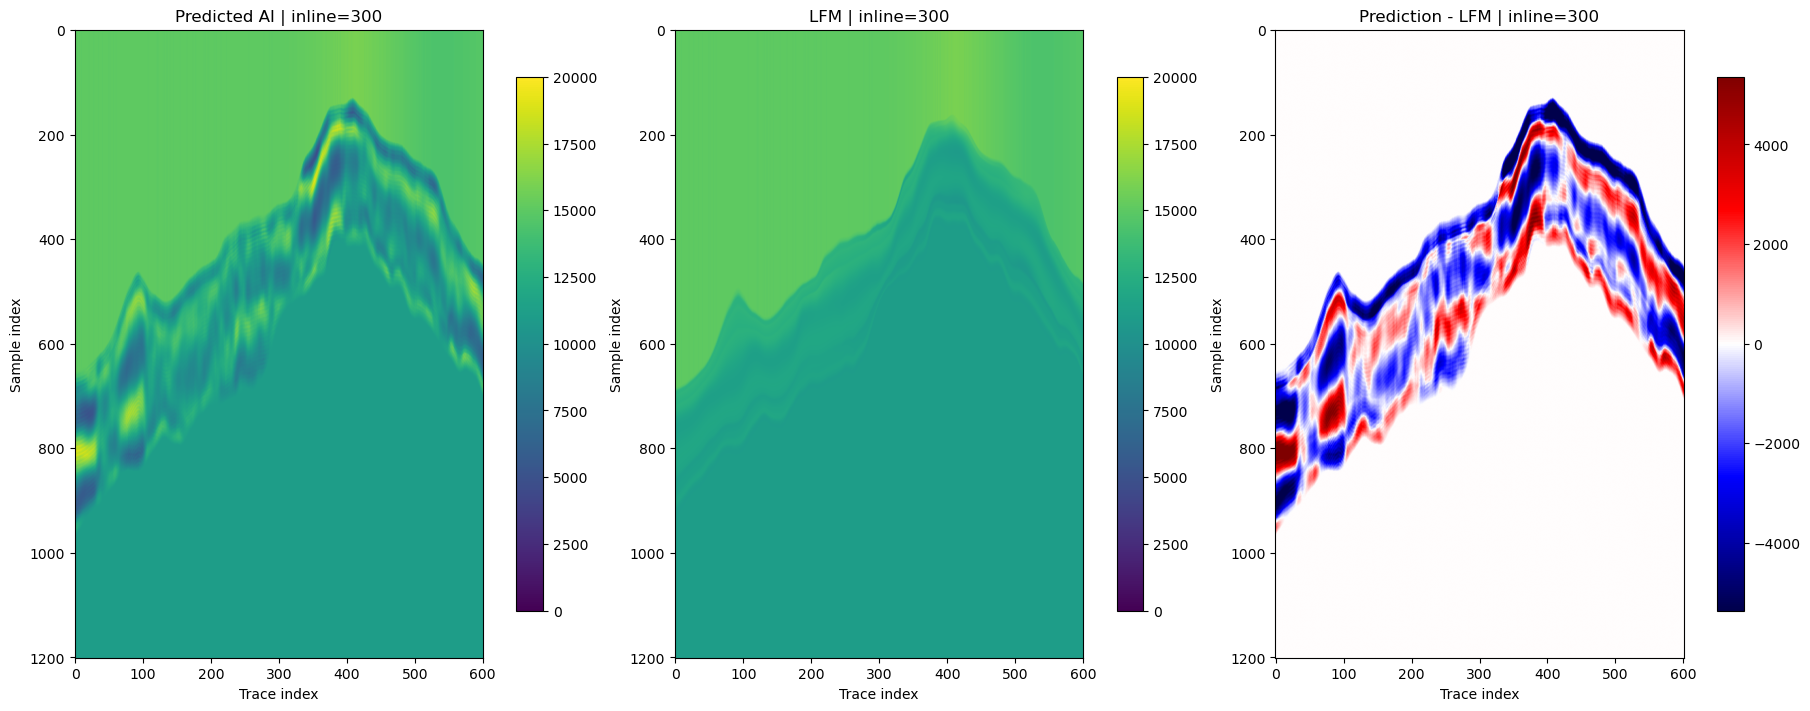

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

im0 = axes[0].imshow(pred_section, cmap="viridis", aspect="auto", origin="upper", vmin=shared_vmin, vmax=shared_vmax)
axes[0].set_title(f"Predicted AI | {slice_mode}={resolved_slice_index}")
axes[0].set_xlabel("Trace index")
axes[0].set_ylabel("Sample index")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(lfm_section, cmap="viridis", aspect="auto", origin="upper", vmin=shared_vmin, vmax=shared_vmax)
axes[1].set_title(f"LFM | {slice_mode}={resolved_slice_index}")
axes[1].set_xlabel("Trace index")
axes[1].set_ylabel("Sample index")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(diff_section, cmap="seismic", aspect="auto", origin="upper", vmin=-diff_abs, vmax=diff_abs)
axes[2].set_title(f"Prediction - LFM | {slice_mode}={resolved_slice_index}")
axes[2].set_xlabel("Trace index")
axes[2].set_ylabel("Sample index")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

figure_path = output_dir / f"{slice_mode}_{resolved_slice_index:04d}_prediction_vs_lfm.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
print("Saved figure to:", figure_path)
plt.show()


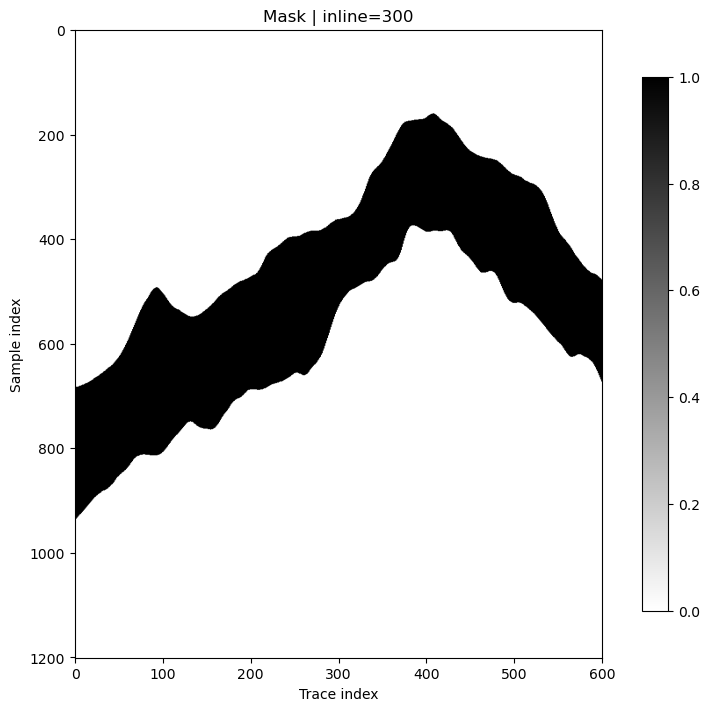

In [7]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
mask_image = np.where(mask_section, 1.0, 0.0)
im = ax.imshow(mask_image, cmap="gray_r", aspect="auto", origin="upper", vmin=0.0, vmax=1.0)
ax.set_title(f"Mask | {slice_mode}={resolved_slice_index}")
ax.set_xlabel("Trace index")
ax.set_ylabel("Sample index")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()


In [8]:
orig_segy_path = Path(cfg.seismic_file)
if not orig_segy_path.exists():
    raise FileNotFoundError(orig_segy_path)

keylocs = [cfg.segy_iline, cfg.segy_xline, cfg.segy_istep, cfg.segy_xstep]
pred_segy_path = output_dir / "pred_volume_best.segy"

pred_volume_export = np.ascontiguousarray(pred_volume.astype(np.float32))


def build_textual_header(title: str, lines: list[str]) -> str:
    rows = [f"C{idx:>2d} {text}"[:80].ljust(80) for idx, text in enumerate([title, *lines], start=1)]
    rows.extend([f"C{idx:>2d}".ljust(80) for idx in range(len(rows) + 1, 41)])
    textual = "".join(rows)
    if len(textual) != 3200:
        raise ValueError(f"Expected 3200-char textual header, got {len(textual)}")
    return textual


pred_textual = build_textual_header(
    "GINN predicted impedance volume",
    [
        f"checkpoint={checkpoint_path.name}",
        f"epoch={checkpoint['epoch']}",
        f"best_loss={checkpoint['best_loss']:.6f}",
    ],
)

cigsegy.create_by_sharing_header(
    str(pred_segy_path),
    str(orig_segy_path),
    pred_volume_export,
    keylocs=keylocs,
    textual=pred_textual,
)

print("Exported predicted impedance SEG-Y to:", pred_segy_path)


Exported predicted impedance SEG-Y to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_prediction\pred_volume_best.segy
